<a href="https://colab.research.google.com/github/joamilab/FormacaoDIO-MachineLearning/blob/modulo3-projeto-dimensaoimagens/Forma%C3%A7%C3%A3o_DIO_ML_M%C3%B3dulo_3_Projeto_Redu%C3%A7%C3%A3o_Dimensionalidade_de_Fotos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
from PIL import Image
from IPython.display import display

In [28]:
def load_image(image_path):
    '''
      Carregar imagem, extrair pixels RGB e dimensões.

      Args:
        image_path (str): Caminho da imagem.

      Returns:
        img (PIL.Image): Imagem carregada.
        widht (int): Largura da imagem.
        height (int): Altura da imagem.
        pixels (list): Lista de pixels RGB da imagem.
    '''

    img = Image.open(image_path)
    img = img.convert("RGB")

    widht, height = img.size
    pixels = list(img.getdata())

    return img, widht, height, pixels

In [29]:
def convert_to_gray(pixels_rgb, widht, height):
    '''
      Converter imagem para tons de cinza.

      Args:
        pixels_rgb (list): Lista de pixels RGB da imagem.
        widht (int): Largura da imagem.
        height (int): Altura da imagem.

      Returns:
        img (PIL.Image): Imagem em tons de cinza.
        pixels_gray (list): Lista de pixels em tons de cinza.
    '''

    pixels_gray = []

    for r, g, b in pixels_rgb:
        # Fórmula padrão de luminância
        gray = int(0.299 * r + 0.587 * g + 0.114 * b)
        pixels_gray.append(gray)

    img = Image.new("L", (widht, height))  # "L" = 8 bits por pixel
    img.putdata(pixels_gray)

    return img, pixels_gray

In [30]:
def binarize(pixels_gray, widht, height, threshold=127):
    '''
      Binarizar imagem (preto e branco).

      Args:
        pixels_gray (list): Lista de pixels em tons de cinza.
        widht (int): Largura da imagem.
        height (int): Altura da imagem.
        threshold (int): Limiar para binarização.

      Returns:
        img (PIL.Image): Imagem binarizada.
        pixels_bin (list): Lista de pixels binarizados.
    '''

    pixels_bin = []

    for g in pixels_gray:
        pixels_bin.append(255 if g > threshold else 0)

    img = Image.new("L", (widht, height))  # "L" = 8 bits por pixel
    img.putdata(pixels_bin)

    return img, pixels_bin

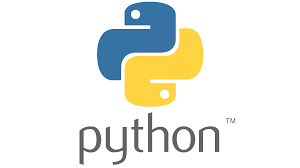

In [31]:
# Caminho da imagem de entrada
path_input = "/content/logo-python.png"

# Carregar imagem
i, w, h, pxl_rgb = load_image(path_input)

display(i)

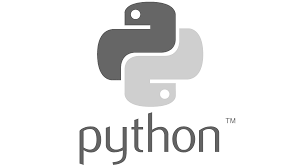

In [32]:
# Converter para tons de cinza
img_gray, pixels_gray = convert_to_gray(pxl_rgb, w, h)

display(img_gray)

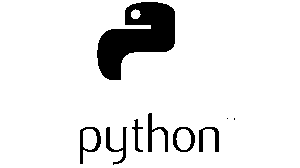

In [33]:
# Binarizar (preto e branco)
img_bin, pixels_bin = binarize(pixels_gray, w, h, threshold=127)

display(img_bin)